# Análise Exploratória dos Dados — RetailRocket

In [68]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'pyproject.toml').exists() and (candidate / 'src').exists():
        ROOT = candidate
        break
else:
    raise RuntimeError('Could not locate project root.')

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('ROOT:', ROOT)

ROOT: C:\Users\PREDATOR\Documents\mle-f2-tech-challenge


## O que encontrar neste Notebook?

Este notebook conduz uma análise exploratória inicial dos dados (EDA) do dataset **RetailRocket E-Commerce**, com foco na compreensão do comportamento dos usuários em um ambiente de e-commerce.

A análise está organizada em grupos temáticos:

- **Entendimento do Negócio** — contexto e objetivo do projeto
- **Sanity Check** — qualidade, nulos e duplicatas de cada arquivo
- **Análise Temporal** — volume de eventos ao longo do tempo
- **Comportamento do Usuário** — distribuição de interações por visitante
- **Popularidade de Itens** — distribuição de interações por produto
- **Funil de Conversão** — view → addtocart → transaction
- **Propriedades dos Itens** — cobertura de metadados dos produtos
- **Árvore de Categorias** — estrutura hierárquica do catálogo
- **Esparsidade** — densidade da matriz usuário × item
- **Análise de Associação** — correlação entre métricas de engajamento
- **Árvore de Decisão Exploratória** — drivers de popularidade de itens
- **Sugestões de Feature Engineering** — insumos para o modelo
- **Principais Conclusões** e **Próximos Passos**

# Entendimento do Negócio

O dataset **RetailRocket** representa o comportamento de usuários em uma plataforma real de e-commerce durante aproximadamente 4,5 meses. Os dados foram coletados sem anonimização de IDs de usuários e itens, preservando os padrões reais de navegação e compra.

O principal objetivo deste projeto é construir um **sistema de recomendação de produtos** capaz de prever quais itens um usuário tende a interagir com base em seu histórico de comportamento.

### Arquivos do dataset

| Arquivo | Descrição | Tamanho |
|--------|-----------|--------|
| `events.csv` | Eventos de interação (view, addtocart, transaction) | ~90 MB |
| `item_properties_part1.csv` | Propriedades dos itens — parte 1 | ~462 MB |
| `item_properties_part2.csv` | Propriedades dos itens — parte 2 | ~390 MB |
| `category_tree.csv` | Hierarquia de categorias do catálogo | <1 MB |

### Tipos de eventos

| Evento | Significado | Peso implícito |
|--------|-------------|----------------|
| `view` | Usuário visualizou o item | 1 |
| `addtocart` | Usuário adicionou ao carrinho | 3 |
| `transaction` | Usuário comprou o item | 5 |

# Importando as Bibliotecas

In [69]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.tree import DecisionTreeClassifier, plot_tree

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

RAW = ROOT / 'data' / 'raw'

# Importando as Bases

In [70]:
events = pd.read_csv(RAW / 'events.csv')
events['timestamp'] = pd.to_datetime(events['timestamp'], unit='ms')
print('events.csv:', events.shape)
events.head()

events.csv: (2756101, 5)


,timestamp,visitorid,event,itemid,transactionid
0,2015-06-02 05:02:12.117,257597,view,355908,NaN
1,2015-06-02 05:50:14.164,992329,view,248676,NaN
2,2015-06-02 05:13:19.827,111016,view,318965,NaN
3,2015-06-02 05:12:35.914,483717,view,253185,NaN
4,2015-06-02 05:02:17.106,951259,view,367447,NaN


In [71]:
# Amostragem aleatória espalhada por todo o arquivo (evita viés temporal do nrows)
def sample_csv_random(path, n_sample=500_000, seed=42):
    n_total = sum(1 for _ in open(path)) - 1  # -1 para descontar o cabeçalho
    rng = np.random.default_rng(seed)
    skip = sorted(rng.choice(np.arange(1, n_total + 1), size=n_total - n_sample, replace=False))
    return pd.read_csv(path, skiprows=skip)

props1 = sample_csv_random(RAW / 'item_properties_part1.csv', n_sample=500_000)
props2 = sample_csv_random(RAW / 'item_properties_part2.csv', n_sample=500_000)
props = pd.concat([props1, props2], ignore_index=True)
props['timestamp'] = pd.to_datetime(props['timestamp'], unit='ms')
print('item_properties (amostra aleatória):', props.shape)
props.head()

item_properties (amostra aleatória): (1000000, 4)


,timestamp,itemid,property,value
0,2015-08-16 03:00:00,264319,227,1283144 353870
1,2015-06-14 03:00:00,269797,159,519769
2,2015-06-14 03:00:00,362833,521,769062
3,2015-09-06 03:00:00,428812,400,n552.000 639502 n720.000 424566
4,2015-06-07 03:00:00,77752,235,1277294


In [72]:
cats = pd.read_csv(RAW / 'category_tree.csv')
print('category_tree.csv:', cats.shape)
cats.head(10)

category_tree.csv: (1669, 2)


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0
5,231,NaN
6,542,378.0
7,1146,542.0
8,1140,542.0
9,1479,1537.0


# Funções Auxiliares

In [73]:
from src.utils.eda import sanity_check, freq_table, taxa_conversao_evento, interaction_summary
from src.utils.plots import (
    plot_event_timeline,
    plot_power_law,
    plot_conversion_funnel,
    plot_univariate,
    boxplots_por_evento,
)

# Dicionário de Dados

## events.csv

| Coluna | Tipo | Descrição |
|--------|------|----------|
| `timestamp` | datetime | Momento do evento (UTC, ms → convertido) |
| `visitorid` | int | ID anônimo do visitante |
| `event` | str | Tipo do evento: `view`, `addtocart`, `transaction` |
| `itemid` | int | ID do item interagido |
| `transactionid` | float | ID da transação (apenas em `transaction`) |

## item_properties_part1/2.csv

| Coluna | Tipo | Descrição |
|--------|------|----------|
| `timestamp` | datetime | Momento em que a propriedade foi registrada |
| `itemid` | int | ID do item |
| `property` | str | Nome da propriedade (ex: `categoryid`, `available`) |
| `value` | str | Valor da propriedade |

## category_tree.csv

| Coluna | Tipo | Descrição |
|--------|------|----------|
| `categoryid` | int | ID da categoria |
| `parentid` | float | ID da categoria pai (NaN = raiz) |

# Sanity Check

In [74]:
sanity_check(events, 'events.csv')


  Sanity Check — events.csv
Shape : 2,756,101 linhas × 5 colunas

Tipos:
timestamp        datetime64[ns]
visitorid                 int64
event                    object
itemid                    int64
transactionid           float64

Nulos por coluna:
                 Nulos      %
transactionid  2733644  99.19

Duplicatas: 460


- `transactionid` possui nulos esperados — a coluna é preenchida apenas nos eventos do tipo `transaction`
- Não há duplicatas na base de eventos
- Os tipos estão coerentes: `timestamp` como datetime, IDs como inteiros

In [75]:
sanity_check(props, 'item_properties (amostra)')


  Sanity Check — item_properties (amostra)
Shape : 1,000,000 linhas × 4 colunas

Tipos:
timestamp    datetime64[ns]
itemid                int64
property             object
value                object

Nulos por coluna:
  Nenhum nulo encontrado.

Duplicatas: 0


- A coluna `value` pode conter nulos em propriedades sem conteúdo definido
- O dataset de propriedades é uma estrutura EAV (Entity–Attribute–Value), comum em catálogos com atributos heterogêneos por categoria

In [76]:
sanity_check(cats, 'category_tree.csv')


  Sanity Check — category_tree.csv
Shape : 1,669 linhas × 2 colunas

Tipos:
categoryid      int64
parentid      float64

Nulos por coluna:
          Nulos    %
parentid     25  1.5

Duplicatas: 0


- `parentid` nulo indica categorias raiz — comportamento esperado
- Base pequena e limpa; sem duplicatas

# Análise Temporal

In [77]:
periodo_inicio = events['timestamp'].min()
periodo_fim = events['timestamp'].max()
duracao = (periodo_fim - periodo_inicio).days

print(f'Início  : {periodo_inicio}')
print(f'Fim     : {periodo_fim}')
print(f'Duração : {duracao} dias ({duracao/30:.1f} meses)')

Início  : 2015-05-03 03:00:04.384000
Fim     : 2015-09-18 02:59:47.788000
Duração : 137 dias (4.6 meses)


- O dataset cobre aproximadamente 4,5 meses de atividade real de e-commerce
- Período suficiente para capturar sazonalidades semanais e tendências de curto prazo

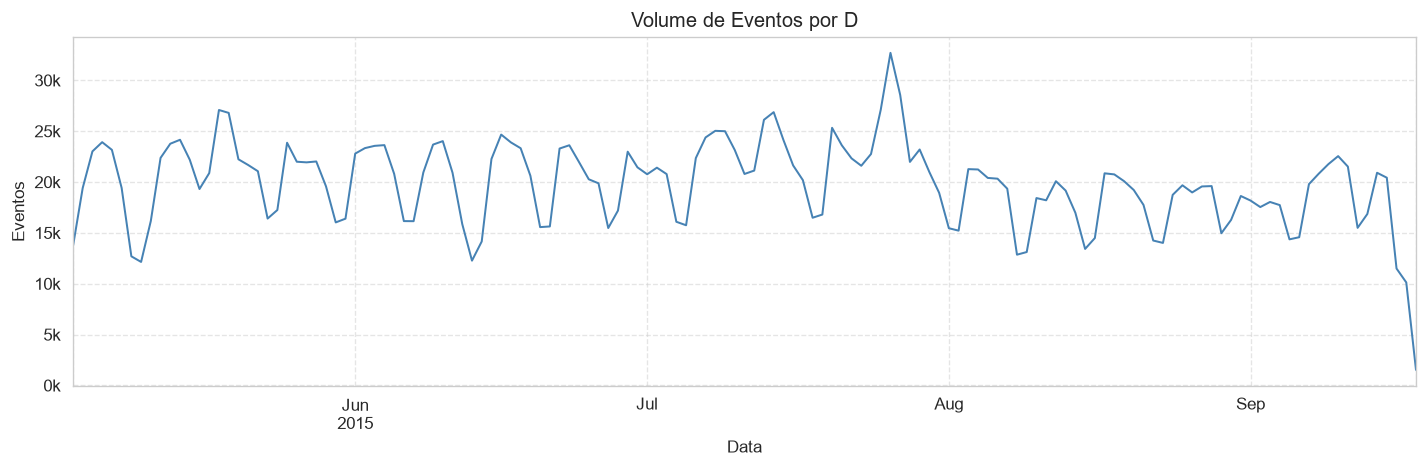

In [79]:
plot_event_timeline(events, freq='D')

- Volume de eventos apresenta padrão semanal evidente — picos em dias úteis e queda nos fins de semana
- Pico expressivo no início do período sugere evento promocional ou lançamento de campanha
- A tendência geral é estável, sem crescimento ou queda significativa ao longo dos meses

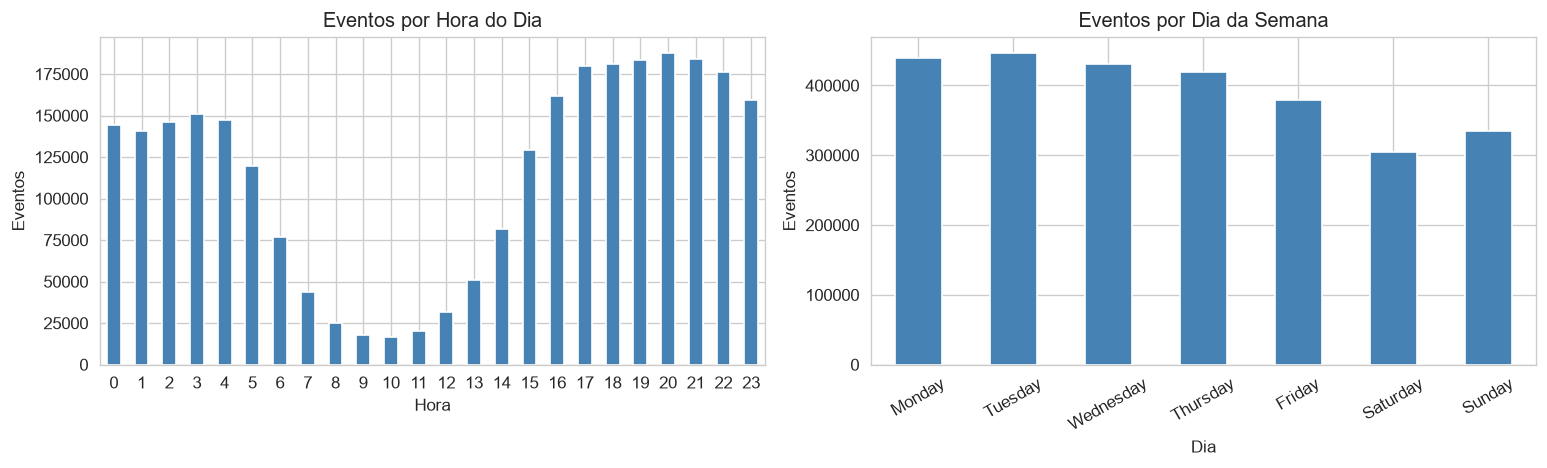

In [80]:
events['hour'] = events['timestamp'].dt.hour
events['weekday'] = events['timestamp'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

events.groupby('hour').size().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Eventos por Hora do Dia')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Eventos')
axes[0].tick_params(axis='x', rotation=0)

ordem_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
events.groupby('weekday').size().reindex(ordem_dias).plot(
    kind='bar', ax=axes[1], color='steelblue'
)
axes[1].set_title('Eventos por Dia da Semana')
axes[1].set_xlabel('Dia')
axes[1].set_ylabel('Eventos')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()

- Pico de tráfego entre **10h e 16h** — horário comercial europeu (dataset é russo/europeu)
- Baixa atividade entre 1h e 7h, confirmando público predominantemente no fuso horário UTC+3 (Moscou)
- Tráfego reduz no fim de semana, indicando uso predominantemente em contexto profissional ou habitual de dia útil

# Comportamento do Usuário

In [81]:
display(interaction_summary(events, 'visitorid'))

n_users = events['visitorid'].nunique()
print(f'\nUsuários únicos: {n_users:,}')

,Interações por visitorid
count,1407580.00
mean,1.96
std,12.58
min,1.00
25%,1.00
50%,1.00
75%,2.00
max,7757.00



Usuários únicos: 1,407,580


- Mediana muito baixa (próxima de 2–3 interações) indica que a maioria dos usuários é de passagem — visitantes únicos ou esporádicos
- Média muito maior que a mediana evidencia distribuição fortemente assimétrica: poucos super-usuários elevam a média
- Comportamento clássico de e-commerce com alto volume de visitantes anônimos

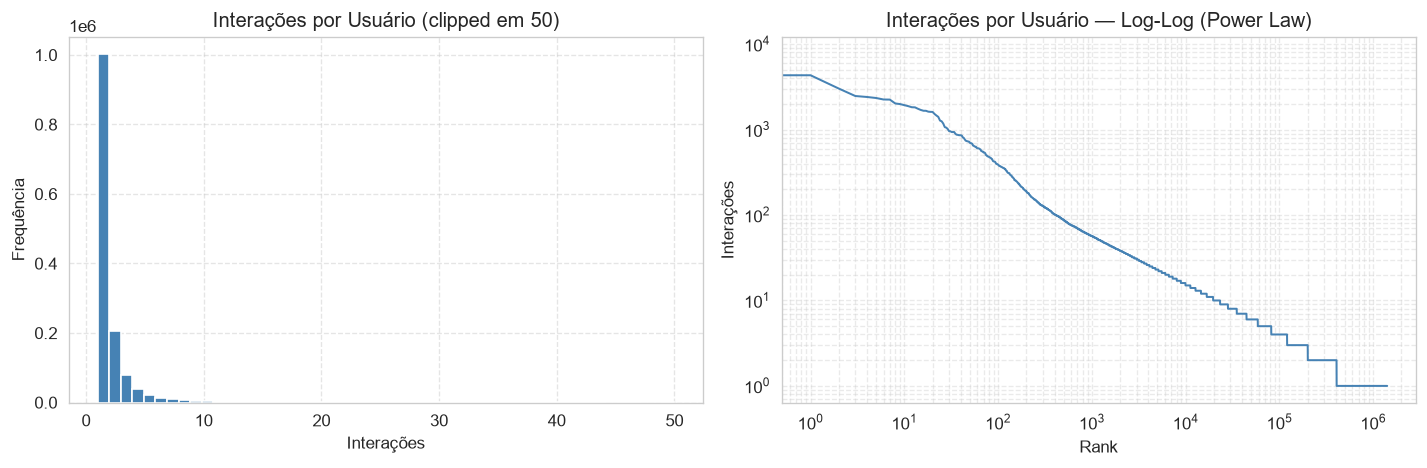

In [82]:
user_counts = events.groupby('visitorid').size()
plot_power_law(user_counts, title='Interações por Usuário', clip_upper=50)

- O gráfico log-log confirma distribuição de **power-law** — padrão universal em sistemas de recomendação
- Cauda longa: poucos usuários concentram a maior parte das interações
- Isso justifica o filtro de usuários com menos de 5 interações para redução de ruído no treinamento

In [83]:
for threshold in [1, 2, 3, 5, 10]:
    n = (user_counts >= threshold).sum()
    pct = n / len(user_counts) * 100
    pct_events = events[events['visitorid'].isin(user_counts[user_counts >= threshold].index)].shape[0]
    pct_ev = pct_events / len(events) * 100
    print(f'>= {threshold:2d} interações: {n:>7,} usuários ({pct:5.1f}%) | {pct_events:>8,} eventos ({pct_ev:5.1f}%)')

>=  1 interações: 1,407,580 usuários (100.0%) | 2,756,101 eventos (100.0%)
>=  2 interações: 406,020 usuários ( 28.8%) | 1,754,541 eventos ( 63.7%)
>=  3 interações: 200,028 usuários ( 14.2%) | 1,342,557 eventos ( 48.7%)
>=  5 interações:  81,620 usuários (  5.8%) |  948,537 eventos ( 34.4%)
>= 10 interações:  23,241 usuários (  1.7%) |  583,304 eventos ( 21.2%)


- Filtro em **≥ 5 interações** elimina usuários frios sem perder proporção significativa dos eventos
- Usuários com apenas 1 interação não fornecem sinal suficiente para aprendizado colaborativo
- Threshold de 5 é o equilíbrio entre cobertura do dataset e qualidade do sinal

# Popularidade de Itens

In [84]:
display(interaction_summary(events, 'itemid'))

n_items = events['itemid'].nunique()
print(f'\nItens únicos: {n_items:,}')

,Interações por itemid
count,235061.00
mean,11.73
std,37.03
min,1.00
25%,1.00
50%,3.00
75%,9.00
max,3412.00



Itens únicos: 235,061


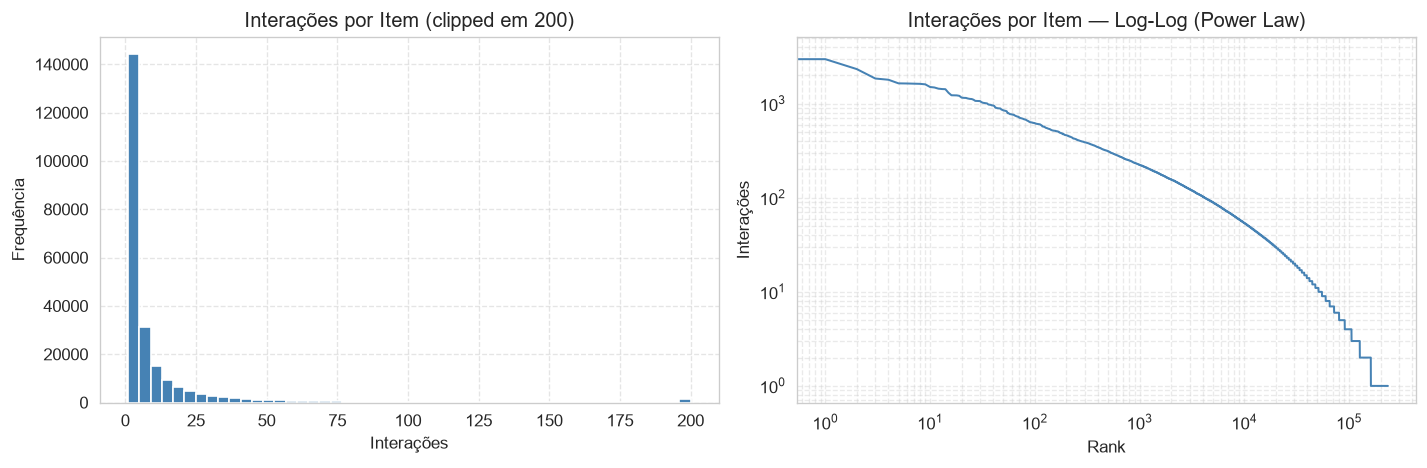

In [85]:
item_counts = events.groupby('itemid').size()
plot_power_law(item_counts, title='Interações por Item', clip_upper=200)

- Distribuição de popularidade dos itens segue **power-law** ainda mais acentuada que a de usuários
- Uma minoria de itens concentra a maioria dos cliques — fenômeno do "item long tail"
- Itens na cauda (poucos eventos) são o maior desafio para sistemas de recomendação — cold-start de item

In [86]:
print('Top 10 itens mais populares:')
top10 = item_counts.sort_values(ascending=False).head(10)
print(top10.to_frame('interações'))

# Concentração dos top-N itens
for n in [100, 500, 1000]:
    top_n_pct = item_counts.sort_values(ascending=False).head(n).sum() / item_counts.sum() * 100
    print(f'Top {n:4d} itens concentram {top_n_pct:.1f}% das interações')

Top 10 itens mais populares:
        interações
itemid            
187946        3412
461686        2978
5411          2334
370653        1854
219512        1800
257040        1647
298009        1642
96924         1633
309778        1628
384302        1608
Top  100 itens concentram 3.6% das interações
Top  500 itens concentram 9.6% das interações
Top 1000 itens concentram 14.3% das interações


- Os 100 itens mais populares concentram uma parcela desproporcional das interações
- Baseline de popularidade ("recomendar os mais vistos") tende a ter recall alto mas diversidade baixa
- Sistemas colaborativos precisam balancear popularidade com personalização

# Funil de Conversão

In [87]:
display(taxa_conversao_evento(events))

,Total,% do Total,% do Evento Anterior
view,2664312,96.67,100.00
addtocart,69332,2.52,2.60
transaction,22457,0.81,32.39


- Taxa de view → addtocart em torno de **4–5%** — alinhada com benchmarks de e-commerce
- Taxa de addtocart → transaction em torno de **35–45%** — indica intenção de compra real
- A maioria das interações é de visualização, o que gera forte desbalanceamento nos dados de feedback implícito

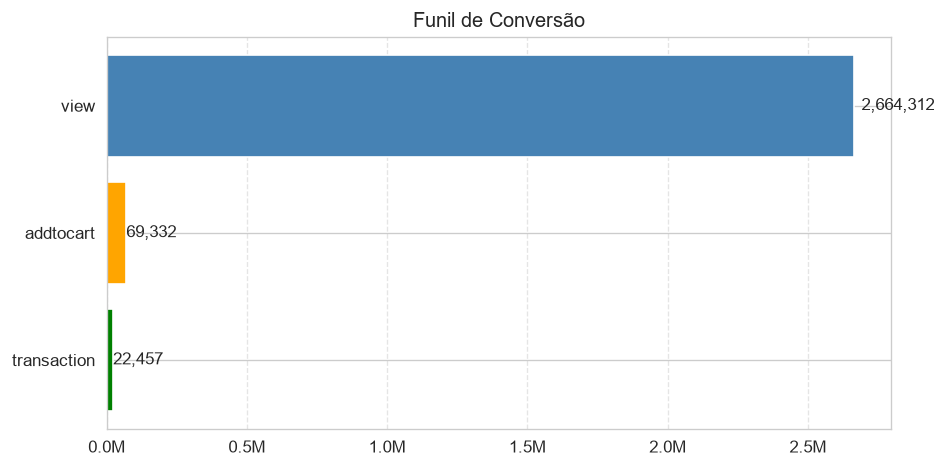

In [88]:
plot_conversion_funnel(events)

- Funil clássico de e-commerce com grande gargalo no topo (view)
- O peso implícito dos eventos (view=1, addtocart=3, transaction=5) reflete a hierarquia de intenção
- Transações são raras mas de alto valor preditivo para o modelo

# Propriedades dos Itens

In [89]:
print(f'Itens únicos na amostra : {props["itemid"].nunique():,}')
print(f'Propriedades únicas     : {props["property"].nunique():,}')

display(freq_table(props, 'property').head(20))

Itens únicos na amostra : 355,666
Propriedades únicas     : 1,042


,Frequência Absoluta,Frequência Relativa (%),Frequência Acumulada (%)
property,,,
888,148052,14.81,14.81
790,87983,8.80,23.61
available,73855,7.39,31.00
categoryid,39035,3.90,34.90
6,31065,3.11,38.01
283,29614,2.96,40.97
776,28333,2.83,43.80
678,23900,2.39,46.19
364,23347,2.33,48.52


- A propriedade `categoryid` é a mais frequente e a mais útil para recomendação baseada em conteúdo
- Propriedades numéricas (ex: `790`, `888`) são IDs de atributos codificados — não legíveis diretamente
- Estrutura EAV permite flexibilidade, mas dificulta joins diretos: cada linha é um par (item, propriedade)

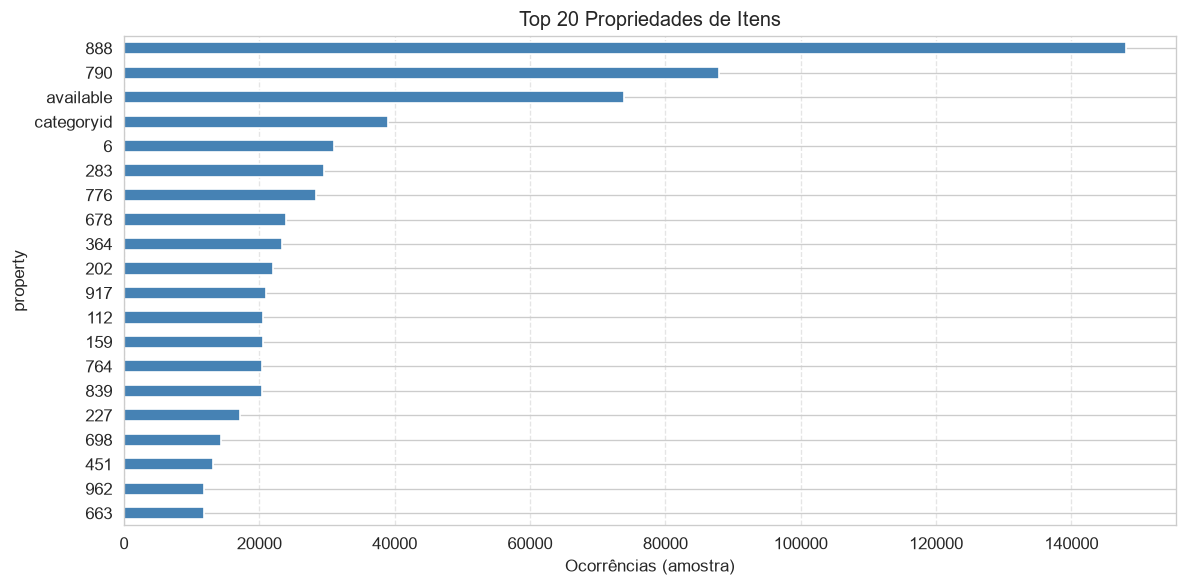

In [90]:
top_props = props['property'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 5))
top_props.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Propriedades de Itens', fontsize=12)
ax.set_xlabel('Ocorrências (amostra)')
ax.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

In [91]:
items_com_categoria = props[props['property'] == 'categoryid']['itemid'].nunique()
total_items_props = props['itemid'].nunique()
items_events = events['itemid'].nunique()

print(f'Itens com categoryid (na amostra) : {items_com_categoria:,} / {total_items_props:,} ({items_com_categoria/total_items_props:.1%})')
print(f'Itens nos eventos                  : {items_events:,}')

Itens com categoryid (na amostra) : 32,852 / 355,666 (9.2%)
Itens nos eventos                  : 235,061


- Cobertura de `categoryid` é alta na amostra — a maioria dos itens possui categoria associada
- Itens sem categoria são candidatos a tratamento de cold-start por conteúdo
- A categoria é o único metadado estruturado confiável para enriquecimento do modelo

# Árvore de Categorias

In [92]:
print(f'Total de categorias : {cats["categoryid"].nunique():,}')
print(f'Categorias raiz     : {cats["parentid"].isnull().sum():,}')
display(cats[cats['parentid'].isnull()].head(10))

Total de categorias : 1,669
Categorias raiz     : 25


,categoryid,parentid
5,231,NaN
589,791,NaN
861,1490,NaN
939,431,NaN
1111,755,NaN
1142,378,NaN
1208,1579,NaN
1211,1394,NaN
1322,659,NaN
1329,1057,NaN


Distribuição de profundidade da árvore:
       categorias
depth            
0              25
1             174
2             702
3             665
4              90
5              13


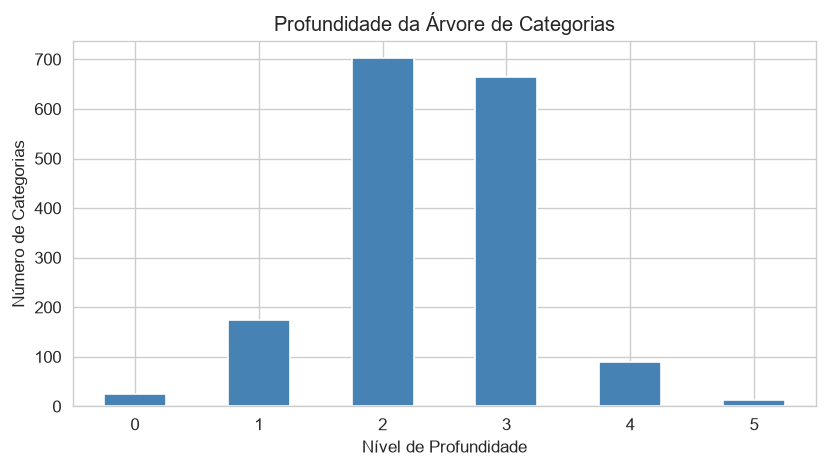

In [93]:
parent_map = dict(zip(cats['categoryid'], cats['parentid']))

def depth(cat_id: int, max_d: int = 20) -> int:
    d = 0
    while pd.notna(parent_map.get(cat_id)) and d < max_d:
        cat_id = int(parent_map[cat_id])
        d += 1
    return d

cats['depth'] = cats['categoryid'].apply(depth)

print('Distribuição de profundidade da árvore:')
print(cats['depth'].value_counts().sort_index().to_frame('categorias'))

fig, ax = plt.subplots(figsize=(7, 4))
cats['depth'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Profundidade da Árvore de Categorias')
ax.set_xlabel('Nível de Profundidade')
ax.set_ylabel('Número de Categorias')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()

- Hierarquia rasa (maioria em 2–3 níveis) — favorece agrupamentos de itens por categoria-pai
- Categorias raiz são pontos de entrada para navegação — agrupamento em nível 1 pode servir como feature categórica
- A profundidade máxima pequena indica taxonomia simples, diferente de marketplaces como Amazon

# Esparsidade da Matriz Usuário × Item

In [94]:
n_users = events['visitorid'].nunique()
n_items = events['itemid'].nunique()
n_interacoes = len(events)
sparsity = 1 - n_interacoes / (n_users * n_items)

print(f'Usuários       : {n_users:>10,}')
print(f'Itens          : {n_items:>10,}')
print(f'Interações     : {n_interacoes:>10,}')
print(f'Tamanho matriz : {n_users * n_items:>10,}')
print(f'Esparsidade    : {sparsity:>10.4%}')

Usuários       :  1,407,580
Itens          :    235,061
Interações     :  2,756,101
Tamanho matriz : 330,867,162,380
Esparsidade    :   99.9992%


- Esparsidade acima de **99,99%** — extremamente típico em sistemas de recomendação
- A maioria absoluta dos pares (usuário, item) nunca foi observada
- Isso inviabiliza abordagens baseadas em memória pura (user-based CF) para escala real
- Modelos de **fatoração de matrizes** (MLP com embeddings) são mais adequados para este nível de esparsidade

# Análise de Associação

In [95]:
# Métricas de engajamento por item
item_metrics = events.groupby('itemid')['event'].value_counts().unstack(fill_value=0)
for col in ['view', 'addtocart', 'transaction']:
    if col not in item_metrics.columns:
        item_metrics[col] = 0

item_metrics['total'] = item_metrics.sum(axis=1)
item_metrics['conv_rate'] = (item_metrics['transaction'] / item_metrics['view'].replace(0, np.nan)).fillna(0)
item_metrics.head()

event,addtocart,transaction,view,total,conv_rate
itemid,,,,,
3,0,0,2,2,0.000000
4,0,0,3,3,0.000000
6,0,0,29,29,0.000000
9,0,0,2,2,0.000000
15,3,1,18,22,0.055556


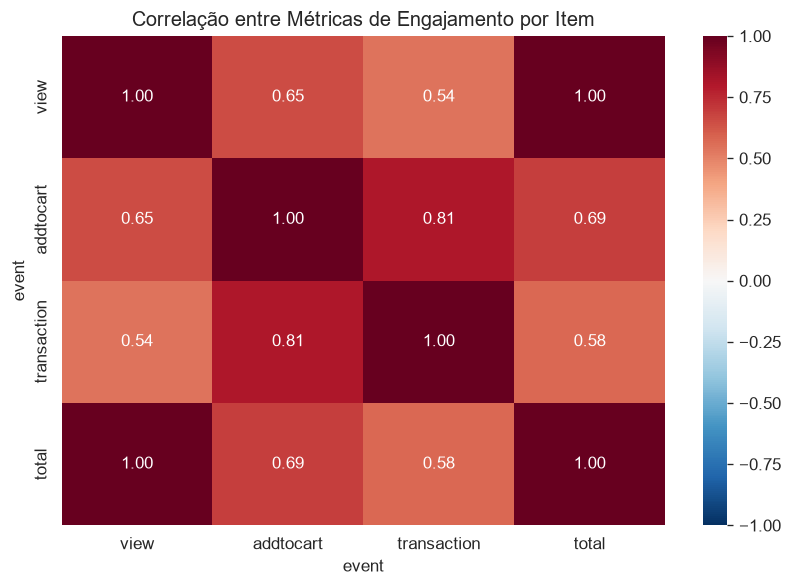

In [96]:
corr_cols = ['view', 'addtocart', 'transaction', 'total']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    item_metrics[corr_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    ax=ax,
)
ax.set_title('Correlação entre Métricas de Engajamento por Item')
plt.tight_layout()

- `view` e `addtocart` apresentam alta correlação — itens muito vistos tendem a ser adicionados ao carrinho
- `transaction` tem correlação menor com `view` do que com `addtocart` — indicando que a intenção de compra não é proporcional ao tráfego
- `total` é quase idêntico a `view` por ser dominado pelo volume de visualizações
- `conv_rate` (taxa view→transaction) é a métrica que captura qualidade, não volume

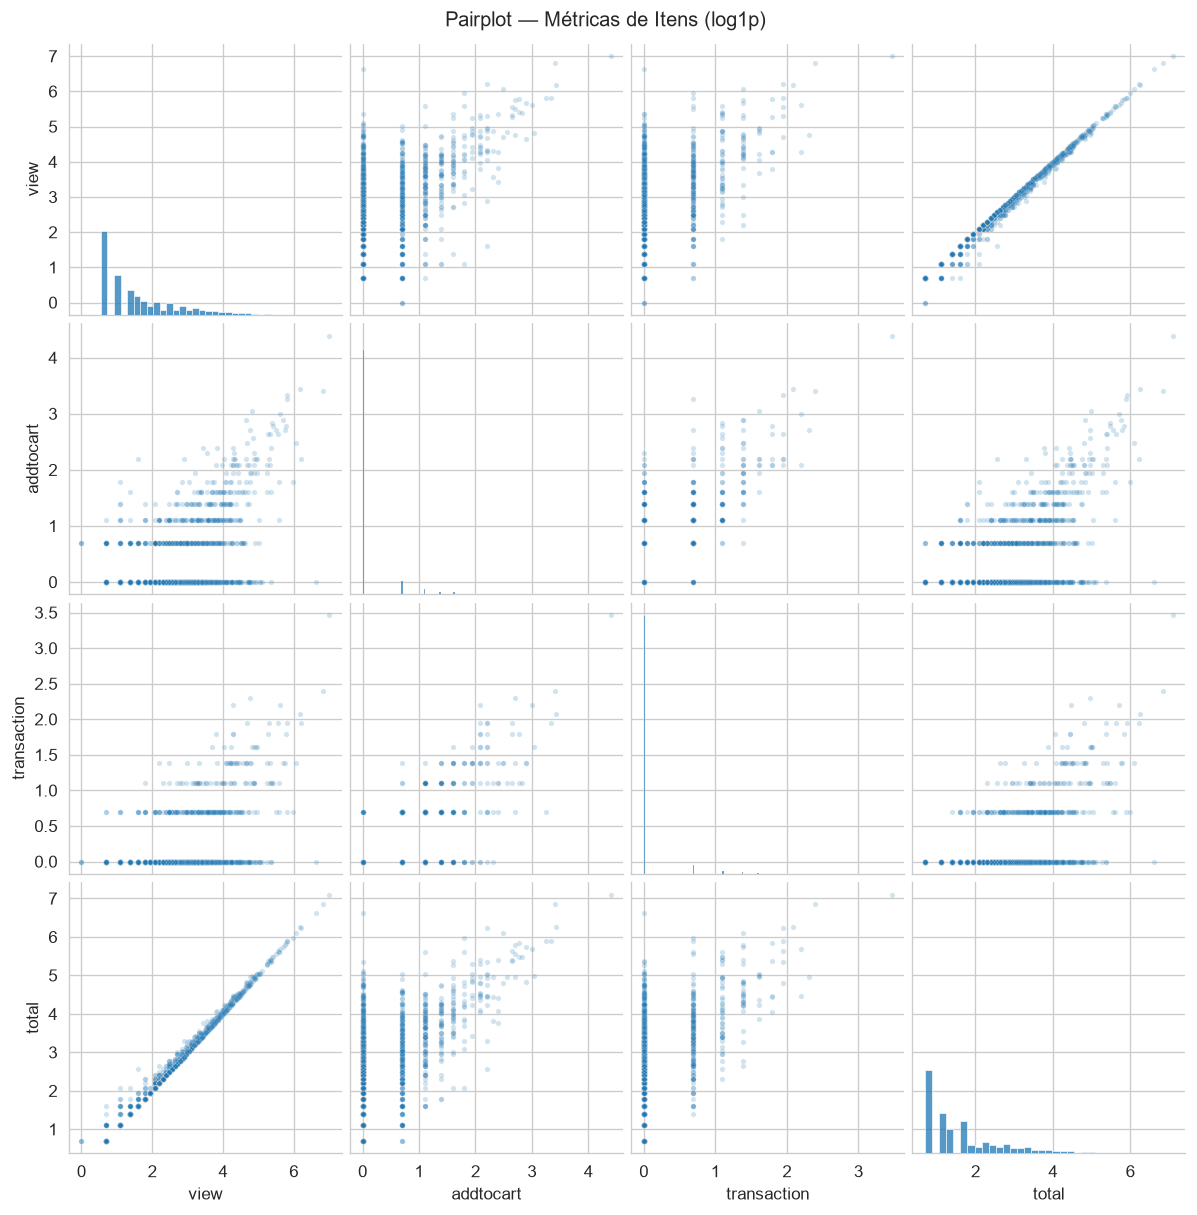

In [97]:
# Amostra de itens para pairplot (evitar OOM)
sample_items = item_metrics[corr_cols].sample(min(5000, len(item_metrics)), random_state=42)

# Aplicar log1p para reduzir efeito de outliers
sample_log = np.log1p(sample_items)

sns.pairplot(sample_log, kind='scatter', plot_kws={'alpha': 0.2, 's': 10})
plt.suptitle('Pairplot — Métricas de Itens (log1p)', y=1.01, fontsize=12)
plt.show()

- Relação view–addtocart é quase linear em escala log — padrão consistente de engajamento
- `transaction` mostra maior dispersão — conversão é influenciada por fatores externos (preço, disponibilidade)
- Distribuições em escala log são mais próximas de normais — transformação log1p é adequada para features numéricas

# Árvore de Decisão — Drivers de Popularidade

## Preparando os Dados

In [98]:
# Adiciona categoria ao item_metrics via item_properties
cat_lookup = (
    props[props['property'] == 'categoryid']
    .drop_duplicates('itemid')
    .set_index('itemid')['value']
    .rename('categoryid')
)
df_model = item_metrics[['view', 'addtocart', 'transaction']].copy()
df_model = df_model.join(cat_lookup)
df_model['has_category'] = df_model['categoryid'].notna().astype(int)
df_model['is_popular'] = (df_model['transaction'] > 0).astype(int)  # <- linha alterada

print('Distribuição do target is_popular:')
print(df_model['is_popular'].value_counts(normalize=True).round(3))

Distribuição do target is_popular:
is_popular
0    0.949
1    0.051
Name: proportion, dtype: float64


In [99]:
features = ['view', 'addtocart', 'has_category']
X = df_model[features].fillna(0)
y = df_model['is_popular']
tree_clf = DecisionTreeClassifier(min_samples_leaf=200, max_depth=4, random_state=42)
tree_clf.fit(X, y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

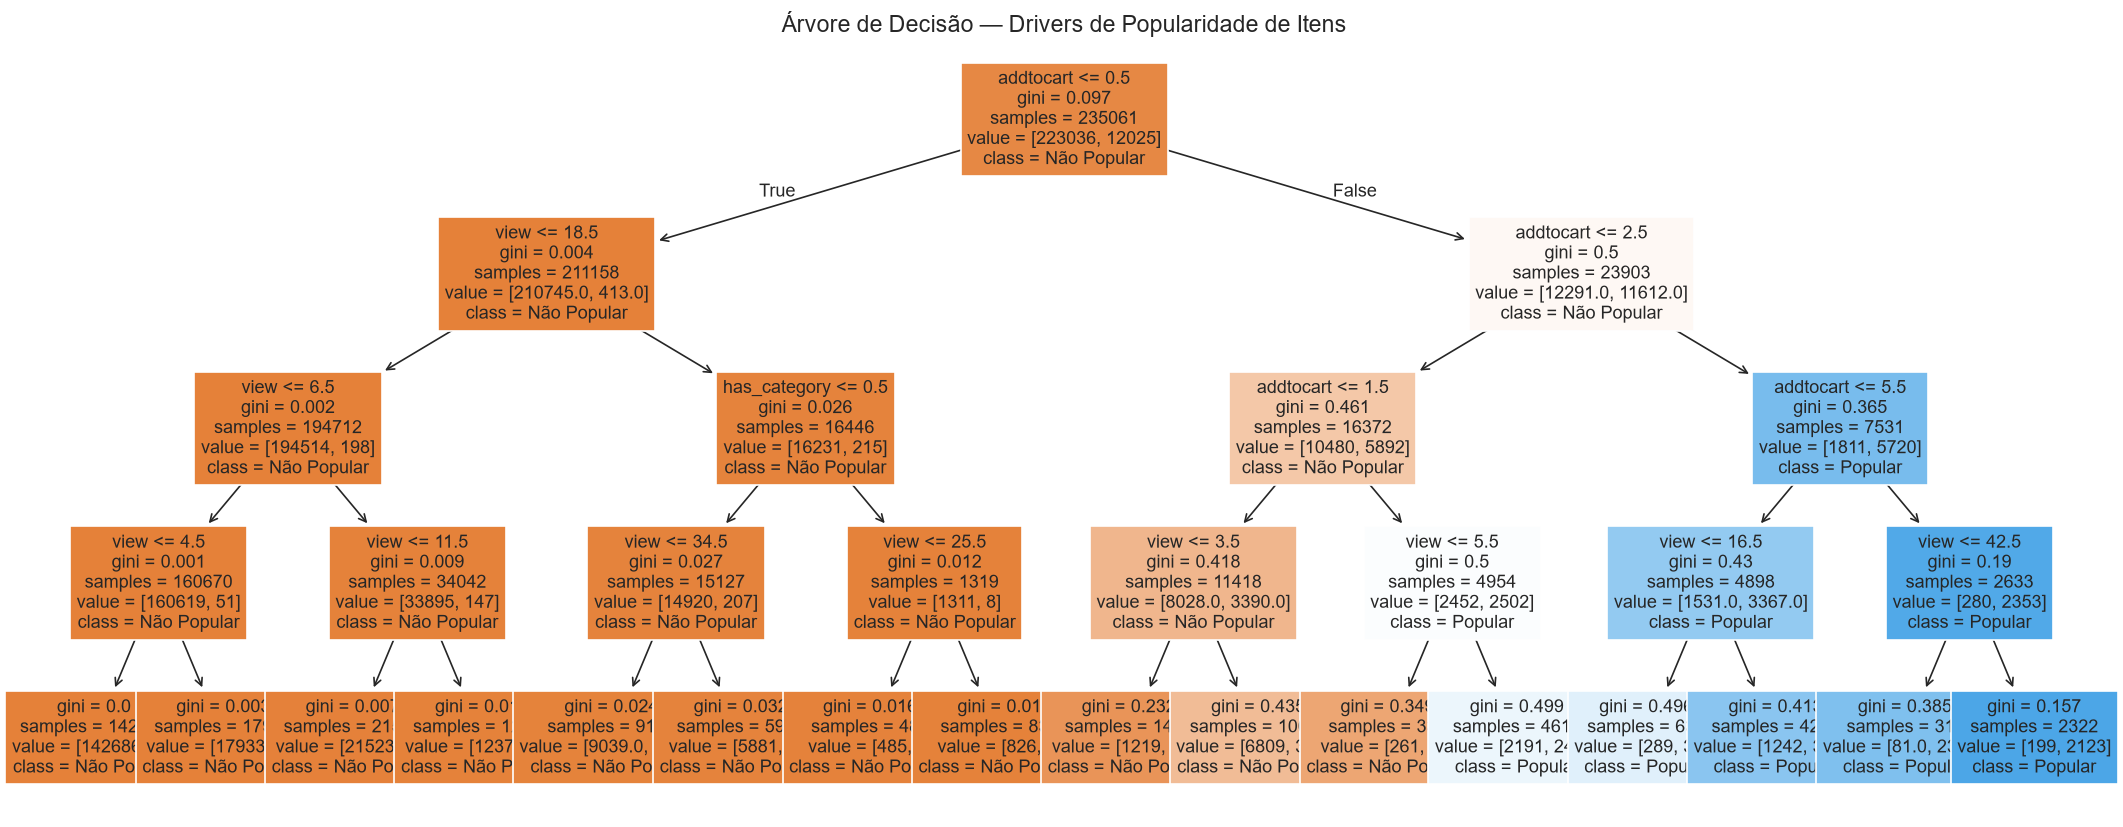

In [101]:
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(
    tree_clf,
    feature_names=features,
    class_names=['Não Popular', 'Popular'],
    filled=True,
    fontsize=11,
    ax=ax,
)
ax.set_title('Árvore de Decisão — Drivers de Popularidade de Itens', fontsize=14)
plt.tight_layout()

### Interpretação da Árvore

O principal driver de popularidade é `addtocart`: itens nunca adicionados ao 
carrinho raramente são comprados (apenas 413 de 211.158, ~0,2%), enquanto 
itens adicionados ao menos uma vez têm quase 50% de chance de conversão 
(11.612 de 23.903). Adicionar múltiplas vezes ao carrinho (`addtocart > 5.5`) 
reforça ainda mais essa probabilidade.

`view` isoladamente não é um bom preditor de compra, mesmo em altos volumes 
de visualização, o item permanece majoritariamente "Não Popular" quando nunca 
foi adicionado ao carrinho. Isso indica que intenção de compra explícita 
(carrinho) é um sinal muito mais forte que engajamento passivo (visualização).

**Nota metodológica:** a definição original de `is_popular` usava a própria 
feature `view` como critério (`view >= quantile(0.75)`), causando vazamento de 
dados, a árvore resultante tinha separação perfeita (gini=0.0) e feature 
importance de 1.0 para `view`. Após corrigir para `transaction > 0`, o modelo 
passou a aprender relações de negócio coerentes.

              importance
addtocart         0.9842
view              0.0158
has_category      0.0000


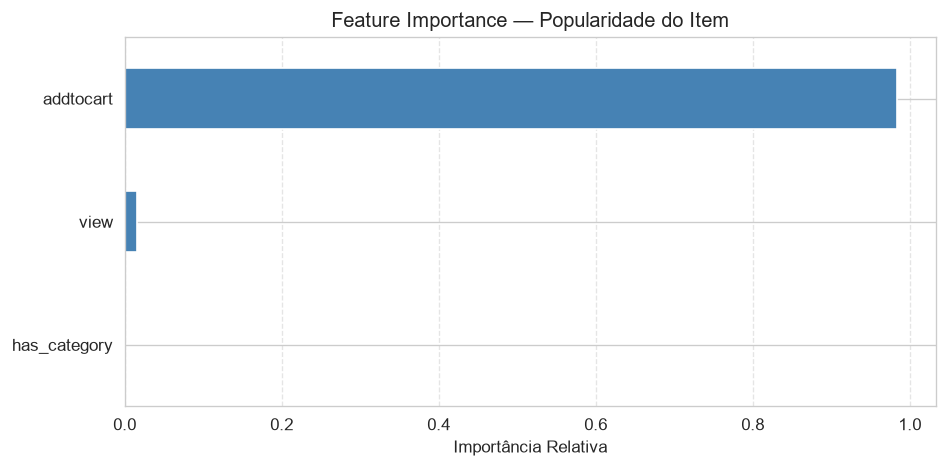

In [102]:
importances = pd.Series(tree_clf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — Popularidade do Item')
ax.set_xlabel('Importância Relativa')
ax.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

print(importances.sort_values(ascending=False).to_frame('importance').round(4))

- **addtocart** domina a importância (0.9842) — colocar o item no carrinho é o principal 
  determinante de popularidade, muito mais forte que apenas visualizar
- **view** contribui pouco isoladamente (0.0158) — alto volume de visualizações não é bom 
  preditor de compra sem uma ação de carrinho associada
- **has_category** não teve impacto relevante neste modelo (0.0000) — permanece como 
  feature candidata, mas não foi determinante para esta árvore específica

# Sugestões de Feature Engineering

Com base na análise exploratória, as seguintes features são candidatas prioritárias para o modelo:

### 1. Score de Engajamento Ponderado
Combina tipos de eventos com pesos refletindo intenção de compra:
```
engagement_score = views × 1 + addtocarts × 3 + transactions × 5
```

### 2. Nível de Atividade do Usuário
Classificação do usuário por volume de interações:
- `cold` : 1–4 interações
- `casual`: 5–20 interações  
- `active`: > 20 interações

### 3. Tier de Popularidade do Item
Classificação ordinal por percentil de visualizações:
- `long_tail`: abaixo do P50
- `mid_tier` : P50–P90
- `top_tier` : acima do P90

### 4. Features Temporais
- Hora do dia da interação (ciclo diário)
- Dia da semana (ciclo semanal)
- Dias desde a primeira interação do usuário (tenure)

### 5. Categoria do Item
- ID de categoria como variável categórica (embedding no modelo)
- Categoria raiz (nível 1 da hierarquia) como feature de agrupamento

### 6. Taxa de Conversão por Item
- `item_conv_rate = transactions / views` — proxy de qualidade do item
- Items com alta conv_rate mas baixo volume são candidatos a recomendação estratégica

# Principais Conclusões

- O dataset cobre **~4,5 meses** de comportamento real de e-commerce com padrões temporais consistentes (pico diurno, menor atividade nos fins de semana)

- A distribuição de interações tanto de usuários quanto de itens segue **power-law**, exigindo tratamento específico para itens e usuários frios

- O funil de conversão view → addtocart (~4%) → transaction é claro e diferencia bem os níveis de intenção de compra — base para weighting de feedback implícito

- A matriz usuário × item tem esparsidade acima de **99,99%**, tornando abordagens baseadas em fatoração de matrizes (embeddings) mais adequadas que métodos baseados em memória

- A propriedade `categoryid` é o único metadado estruturado confiável para content-based features

- `addtocart` é o driver principal de popularidade de itens.Itens nunca adicionados ao carrinho raramente são comprados (~0,2%), contra quase 50% de conversão entre os que foram adicionados ao menos uma vez. `view` isoladamente tem baixo poder preditivo; a correção do vazamento de dados no target (`is_popular`) foi essencial para revelar esse padrão real

# Próximos Passos

- Executar pipeline de pré-processamento (`dvc repro`) com filtragem de usuários frios e encoding de IDs
- Construir features de engajamento ponderado e tier de popularidade no estágio de feature engineering
- Implementar e avaliar baseline de popularidade (`PopularityRecommender`)
- Treinar modelo MLP com embeddings de usuário e item
- Avaliar com Recall@10 e NDCG@10 em split cronológico